In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, CSVLogger
from tensorflow.keras.regularizers import l2
import random
import shutil
from sklearn.model_selection import train_test_split

In [2]:
!git clone https://github.com/Dzakiyaadila/flower-datasets.git

Cloning into 'flower-datasets'...
remote: Enumerating objects: 4993, done.
remote: Total 4993 (delta 0), reused 0 (delta 0), pack-reused 4993 (from 1)
Receiving objects: 100% (4993/4993), 239.95 MiB | 24.91 MiB/s, done.
Updating files: 100% (5000/5000), done.


In [3]:
source_dir = 'flower-datasets'
target_dir = 'dataset_split'

classes = ['Lilly', 'Lotus', 'Orchid', 'Sunflower', 'Tulip']

# Hapus folder lama jika ada
if os.path.exists(target_dir):
    shutil.rmtree(target_dir)

# Buat struktur folder
for split in ['train', 'val', 'test']:
    for cls in classes:
        os.makedirs(os.path.join(target_dir, split, cls), exist_ok=True)

# Split dengan rasio 70% train, 15% val, 15% test
for cls in classes:
    img_files = [f for f in os.listdir(os.path.join(source_dir, cls))
                 if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    random.shuffle(img_files)

    n = len(img_files)
    train_end = int(0.7 * n)
    val_end = int(0.85 * n)

    train_files = img_files[:train_end]
    val_files = img_files[train_end:val_end]
    test_files = img_files[val_end:]

    for f in train_files:
        shutil.copy(os.path.join(source_dir, cls, f), os.path.join(target_dir, 'train', cls, f))
    for f in val_files:
        shutil.copy(os.path.join(source_dir, cls, f), os.path.join(target_dir, 'val', cls, f))
    for f in test_files:
        shutil.copy(os.path.join(source_dir, cls, f), os.path.join(target_dir, 'test', cls, f))

    print(f"{cls}: Train={len(train_files)}, Val={len(val_files)}, Test={len(test_files)}")

Lilly: Train=699, Val=150, Test=150
Lotus: Train=700, Val=150, Test=150
Orchid: Train=700, Val=150, Test=150
Sunflower: Train=700, Val=150, Test=150
Tulip: Train=700, Val=150, Test=150


In [4]:
IMG_HEIGHT, IMG_WIDTH = 180, 180
BATCH_SIZE = 64

train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    brightness_range=[0.8, 1.2],
    validation_split=0.0
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    os.path.join(target_dir, 'train'),
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_test_datagen.flow_from_directory(
    os.path.join(target_dir, 'val'),
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = val_test_datagen.flow_from_directory(
    os.path.join(target_dir, 'test'),
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

class_names = list(train_generator.class_indices.keys())
print("Kelas:", class_names)

Found 3499 images belonging to 5 classes.
Found 750 images belonging to 5 classes.
Found 750 images belonging to 5 classes.
Kelas: ['Lilly', 'Lotus', 'Orchid', 'Sunflower', 'Tulip']


In [5]:
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', kernel_regularizer=l2(0.001), input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(256, (3, 3), activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(512, (3, 3), activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    GlobalAveragePooling2D(),

    Dense(256, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.4),
    Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.3),
    Dense(len(class_names), activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 178, 178, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 87, 87, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 41, 41, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 18, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 18, 18, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 7, 7, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,737,413 (6.63 MB)

 Trainable params: 1,735,429 (6.62 MB)

 Non-trainable params: 1,984 (7.75 KB)

In [6]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=12,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=4,
    min_lr=1e-7,
    verbose=1
)

csv_logger = CSVLogger('training_log.csv', append=True)

callbacks = [early_stop, reduce_lr, csv_logger]

In [7]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=40,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/40
55/55 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - accuracy: 0.4841 - loss: 2.5064 - val_accuracy: 0.2053 - val_loss: 2.7210 - learning_rate: 5.0000e-04
Epoch 2/40
55/55 ━━━━━━━━━━━━━━━━━━━━ 41s 743ms/step - accuracy: 0.5544 - loss: 2.2834 - val_accuracy: 0.2333 - val_loss: 2.8484 - learning_rate: 5.0000e-04
Epoch 3/40
55/55 ━━━━━━━━━━━━━━━━━━━━ 40s 725ms/step - accuracy: 0.6013 - loss: 2.1355 - val_accuracy: 0.2160 - val_loss: 2.9069 - learning_rate: 5.0000e-04
Epoch 4/40
55/55 ━━━━━━━━━━━━━━━━━━━━ 40s 732ms/step - accuracy: 0.6408 - loss: 2.0214 - val_accuracy: 0.2333 - val_loss: 2.9821 - learning_rate: 5.0000e-04
Epoch 5/40
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 706ms/step - accuracy: 0.6415 - loss: 2.0080
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0001500000071246177.
55/55 ━━━━━━━━━━━━━━━━━━━━ 42s 759ms/step - accuracy: 0.6445 - loss: 1.9652 - val_accuracy: 0.2000 - val_loss: 3.3796 - learning_rate: 5.0000e-04
Epoch 6/40
55/55 ━━━━━━━━━━━━━━━━━━━━ 82s 759ms/step - accuracy: 0.

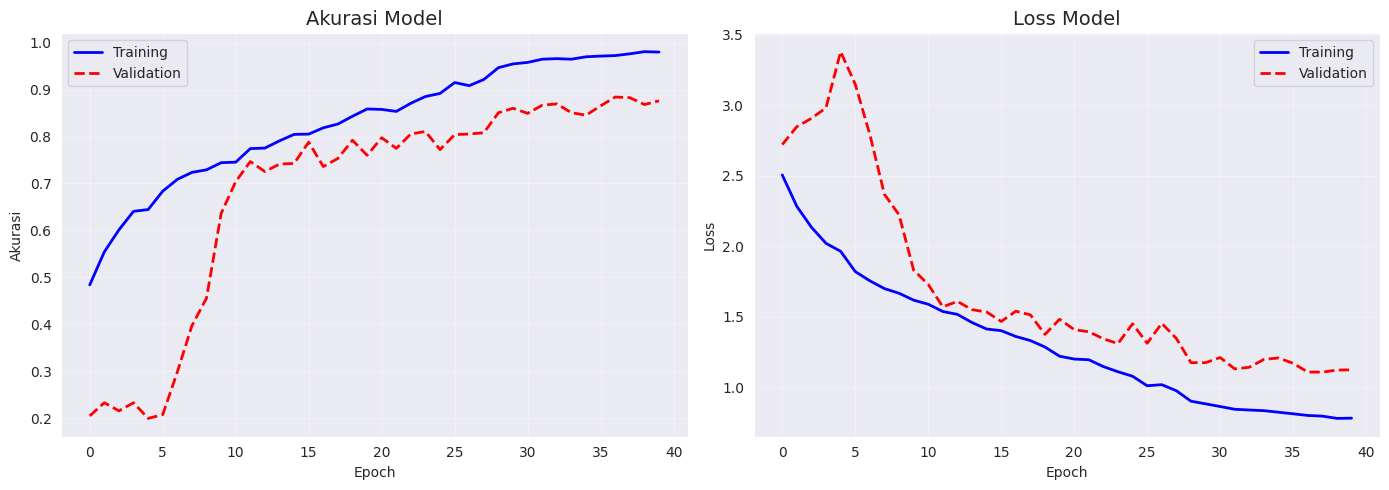

In [8]:
sns.set_style("darkgrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['accuracy'], 'b-', label='Training', linewidth=2)
ax1.plot(history.history['val_accuracy'], 'r--', label='Validation', linewidth=2)
ax1.set_title('Akurasi Model', fontsize=14)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Akurasi')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history.history['loss'], 'b-', label='Training', linewidth=2)
ax2.plot(history.history['val_loss'], 'r--', label='Validation', linewidth=2)
ax2.set_title('Loss Model', fontsize=14)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 316ms/step - accuracy: 0.8893 - loss: 1.0944

Test Accuracy: 0.8893 (88.93%)
Test Loss: 1.0944
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 282ms/step


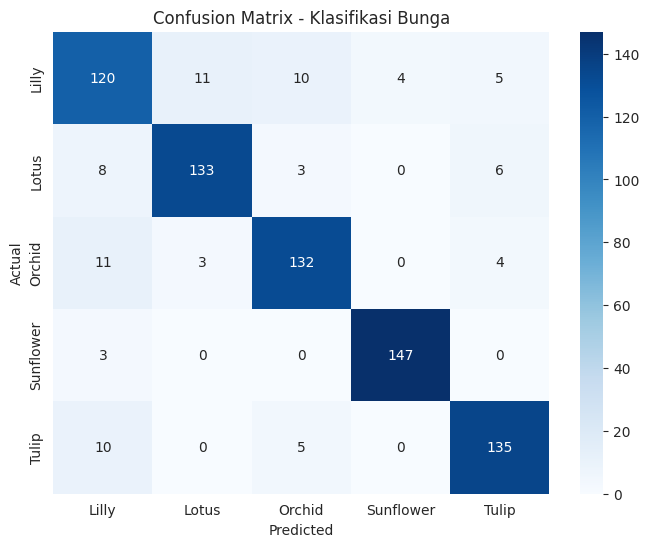


Classification Report:
              precision    recall  f1-score   support

       Lilly       0.79      0.80      0.79       150
       Lotus       0.90      0.89      0.90       150
      Orchid       0.88      0.88      0.88       150
   Sunflower       0.97      0.98      0.98       150
       Tulip       0.90      0.90      0.90       150

    accuracy                           0.89       750
   macro avg       0.89      0.89      0.89       750
weighted avg       0.89      0.89      0.89       750



In [9]:
test_loss, test_acc = model.evaluate(test_generator)
print(f"\n{'='*40}")
print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"Test Loss: {test_loss:.4f}")
print(f"{'='*40}")

# Confusion Matrix
Y_pred = model.predict(test_generator)
y_pred = np.argmax(Y_pred, axis=1)

cm = confusion_matrix(test_generator.classes, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Klasifikasi Bunga')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("\nClassification Report:")
print(classification_report(test_generator.classes, y_pred, target_names=class_names))

In [10]:
# SavedModel
model.export('saved_model', verbose=1)

# TF-Lite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()
with open('model.tflite', 'wb') as f:
    f.write(tflite_model)

# Label untuk TF-Lite
with open('label.txt', 'w') as f:
    for name in class_names:
        f.write(f"{name}\n")

# TFJS
!pip install tensorflowjs -q
model.save('flower_model.h5')
!tensorflowjs_converter --input_format=keras flower_model.h5 tfjs_model

print("✓ Semua model berhasil disimpan")

Saved artifact at 'saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 180, 180, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  138514399146640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138514399147408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138514399149328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138514399149712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138514399146256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138514399148944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138514399148368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138514399149136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138514399149904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138514399148560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138514399149520: Te

2026-05-15 16:30:42.853714: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778862642.874367   15839 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778862642.881173   15839 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778862642.897963   15839 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778862642.898017   15839 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778862642.898022   15839 computation_placer.cc:177] computation placer alr

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


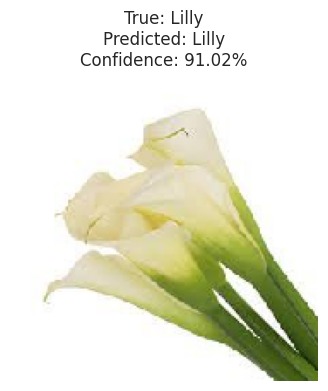

In [11]:
# Ambil 1 gambar dari test set
sample_img, sample_label = next(test_generator)
sample_img = np.expand_dims(sample_img[0], axis=0)

pred = model.predict(sample_img)
pred_class = class_names[np.argmax(pred)]
true_class = class_names[np.argmax(sample_label[0])]

plt.figure(figsize=(4, 4))
plt.imshow(sample_img[0])
plt.title(f'True: {true_class}\nPredicted: {pred_class}\nConfidence: {np.max(pred)*100:.2f}%')
plt.axis('off')
plt.show()

In [12]:
!zip -r submission_flowers.zip saved_model tfjs_model model.tflite label.txt
print("submission_flowers.zip siap diupload!")

  adding: saved_model/ (stored 0%)
  adding: saved_model/variables/ (stored 0%)
  adding: saved_model/variables/variables.index (deflated 71%)
  adding: saved_model/variables/variables.data-00000-of-00001 (deflated 8%)
  adding: saved_model/fingerprint.pb (stored 0%)
  adding: saved_model/assets/ (stored 0%)
  adding: saved_model/saved_model.pb (deflated 88%)
  adding: tfjs_model/ (stored 0%)
  adding: tfjs_model/group1-shard2of2.bin (deflated 8%)
  adding: tfjs_model/model.json (deflated 91%)
  adding: tfjs_model/group1-shard1of2.bin (deflated 8%)
  adding: model.tflite (deflated 8%)
  adding: label.txt (stored 0%)
submission_flowers.zip siap diupload!
